# LSTM Forecast for electricity_local
This notebook builds an LSTM model to forecast the univariate electricity_local series using a 12-step lookback window with MinMax scaling applied after the train-test split.

## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.stattools import adfuller
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

## Load the CSV Dataset

In [2]:
# Load the dataset
df = pd.read_csv('../public/data/combined_air_electricity_ipi_cleaned.csv')

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

target_col = 'electricity_local'
print(f'Forecast target: {target_col}')
print(f"Dataset shape before outlier removal: {df.shape}")
print(f"First 5 rows:")
print(df[['date', target_col]].head())
print(f"Last 5 rows:")
print(df[['date', target_col]].tail())

z_scores = np.abs(zscore(df[target_col]))

df[target_col] = np.where(
    z_scores > 3,
    np.nan,
    df[target_col]
)

df[target_col] = df[target_col].interpolate()
print(f"First 5 rows after outlier smoothing:")
print(df[['date', target_col]].head())
print(f"Last 5 rows after outlier smoothing:")
print(df[['date', target_col]].tail())

Forecast target: electricity_local
Dataset shape before outlier removal: (60, 20)
First 5 rows:
        date  electricity_local
0 2018-01-01       11845.900250
1 2018-02-01       11091.957006
2 2018-03-01       12244.089947
3 2018-04-01       12018.584577
4 2018-05-01       12267.998390
Last 5 rows:
         date  electricity_local
55 2022-08-01       13463.730428
56 2022-09-01       13090.583108
57 2022-10-01       13214.603633
58 2022-11-01       12934.276582
59 2022-12-01       13041.875463
First 5 rows after outlier smoothing:
        date  electricity_local
0 2018-01-01       11845.900250
1 2018-02-01       11091.957006
2 2018-03-01       12244.089947
3 2018-04-01       12018.584577
4 2018-05-01       12267.998390
Last 5 rows after outlier smoothing:
         date  electricity_local
55 2022-08-01       13463.730428
56 2022-09-01       13090.583108
57 2022-10-01       13214.603633
58 2022-11-01       12934.276582
59 2022-12-01       13041.875463


## Parse Dates and Sort Data

In [3]:
print(f"Date range: {df['date'].min()} to {df['date'].max()}")

Date range: 2018-01-01 00:00:00 to 2022-12-01 00:00:00


## Create Time Series Index and Target

In [4]:
df.set_index('date', inplace=True)
df[f'log_{target_col}'] = np.log(df[target_col])
log_series = df[f'log_{target_col}']
print(f'Log transformation applied to {target_col}.')

def run_adf_test(series, alpha=0.05):
    result = adfuller(series, autolag='AIC')
    print(f'ADF statistic: {result[0]:.4f}, p-value: {result[1]:.4f}, usedlag: {result[2]}, nobs: {result[3]}')
    return result[1] <= alpha

difference_order = 0
processed_series = log_series.copy()
print('ADF test on log-transformed series:')
if not run_adf_test(processed_series):
    processed_series = processed_series.diff().dropna()
    difference_order = 1
    print('Series was not stationary. Applied first-order differencing.')
    print('ADF test after first differencing:')
    if not run_adf_test(processed_series):
        processed_series = processed_series.diff().dropna()
        difference_order = 2
        print('Series still not stationary. Applied second-order differencing.')
        print('ADF test after second differencing:')
        if not run_adf_test(processed_series):
            print('Warning: series is still non-stationary after second differencing.')

if difference_order == 0:
    print('Final series uses log-transformed values with no differencing.')
else:
    print(f'Final series uses log-transformed values with differencing order = {difference_order}.')

print(f'Final processed data length: {len(processed_series)}')
data = processed_series.values.reshape(-1, 1)
print(f'Data shape: {data.shape}')

Log transformation applied to electricity_local.
ADF test on log-transformed series:
ADF statistic: -4.3711, p-value: 0.0003, usedlag: 0, nobs: 59
Final series uses log-transformed values with no differencing.
Final processed data length: 60
Data shape: (60, 1)


## Split Data into Train and Test (Last 12 Months)

In [5]:
test_size = 12
train_data = data[:-test_size]
test_data = data[-test_size:]

print(f'Train data shape: {train_data.shape}')
print(f'Test data shape: {test_data.shape}')
print(f'Train range: {len(train_data)} months')
print(f'Test range: {len(test_data)} months')

Train data shape: (48, 1)
Test data shape: (12, 1)
Train range: 48 months
Test range: 12 months


## Scale Data with MinMaxScaler After Split

In [6]:
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

print(f'Scaled train shape: {train_scaled.shape}')
print(f'Scaled test shape: {test_scaled.shape}')
print(f'Scaler min: {scaler.data_min_[0]:.2f}, max: {scaler.data_max_[0]:.2f}')

Scaled train shape: (48, 1)
Scaled test shape: (12, 1)
Scaler min: 9.31, max: 9.48


## Create LSTM Input Sequences

In [7]:
def create_sequences(data, lookback=3):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i, 0:1])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

lookback = 3

X_train, y_train = create_sequences(train_scaled, lookback)

test_extended = np.vstack((train_scaled[-lookback:], test_scaled))
X_test, y_test = create_sequences(test_extended, lookback)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'Selected lookback from ACF: {lookback}')

X_train shape: (45, 3, 1)
X_test shape: (12, 3, 1)
Selected lookback from ACF: 3


## Train the Model

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

print('Training the LSTM model with walk-forward validation...')

def create_model(lookback=3):
    model = Sequential([
        LSTM(8, input_shape=(lookback, 1),
             kernel_regularizer=l2(1e-4),
             recurrent_regularizer=l2(1e-4)),
        Dense(4, activation='relu', kernel_regularizer=l2(1e-4)),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def walk_forward_validation(scaled_data, lookback=3, val_size=4, n_splits=3):
    total_len = len(scaled_data)
    max_splits = (total_len - lookback - val_size) // val_size
    if max_splits < 1:
        raise ValueError('Not enough data for walk-forward validation with the given parameters.')

    n_splits = min(n_splits, max_splits)
    metrics = []

    for split in range(n_splits):
        initial_train_size = 20           # reduced: 30 was too large for 48 pts
        train_end = initial_train_size + (split + 1) * val_size
        val_start = train_end
        val_end = val_start + val_size

        if val_end > total_len:
            print(f'Fold {split + 1}: not enough data, skipping.')
            break

        train_window = scaled_data[:train_end]
        val_window = scaled_data[val_start:val_end]

        X_train_w, y_train_w = create_sequences(train_window, lookback)
        X_val_w, y_val_w = create_sequences(
            np.vstack((train_window[-lookback:], val_window)),
            lookback
        )

        fold_model = create_model(lookback)
        fold_model.fit(
            X_train_w,
            y_train_w,
            epochs=200,                   # more epochs, early stopping will brake
            batch_size=2,                 # tiny batch for small data
            validation_data=(X_val_w, y_val_w),
            callbacks=[
                EarlyStopping(
                    monitor='val_loss',
                    patience=20,          # more patience to avoid premature stop
                    restore_best_weights=True,
                    verbose=0
                ),
                ReduceLROnPlateau(        # decay LR when val_loss plateaus
                    monitor='val_loss',
                    factor=0.5,
                    patience=10,
                    min_lr=1e-5,
                    verbose=0
                )
            ],
            shuffle=False,
            verbose=0
        )

        y_val_pred = fold_model.predict(X_val_w, verbose=0)
        mae = mean_absolute_error(y_val_w, y_val_pred)
        rmse = np.sqrt(mean_squared_error(y_val_w, y_val_pred))
        r2 = r2_score(y_val_w, y_val_pred)
        metrics.append((mae, rmse, r2))

        print(
            f'Fold {split + 1}: train_end={train_end}, val_end={val_end}, '
            f'MAE={mae:.6f}, RMSE={rmse:.6f}, R²={r2:.6f}'
        )

    return metrics

# val_size=4, n_splits=3 — keeps each fold's val set small and folds feasible
metrics = walk_forward_validation(train_scaled, lookback=lookback, val_size=4, n_splits=3)

mae_values = [m[0] for m in metrics]
rmse_values = [m[1] for m in metrics]
r2_values = [m[2] for m in metrics]

print('Walk-forward validation summary:')
print(f'Average MAE:  {np.mean(mae_values):.6f}')
print(f'Average RMSE: {np.mean(rmse_values):.6f}')
print(f'Average R²:   {np.mean(r2_values):.6f}')

print('Training final model on the full training set...')
model = create_model(lookback)
history = model.fit(
    X_train,
    y_train,
    epochs=200,
    batch_size=2,                         # small batch for final train too
    validation_split=0.15,
    callbacks=[
        EarlyStopping(
            monitor='val_loss',
            patience=20,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=10,
            min_lr=1e-5,
            verbose=1
        )
    ],
    shuffle=False,
    verbose=1
)

print('Training completed!')

Training the LSTM model with walk-forward validation...
Fold 1: train_end=24, val_end=28, MAE=0.182218, RMSE=0.197974, R²=0.114112
Fold 2: train_end=28, val_end=32, MAE=0.200992, RMSE=0.205585, R²=-0.000000
Fold 3: train_end=32, val_end=36, MAE=0.113761, RMSE=0.126103, R²=-0.148385
Walk-forward validation summary:
Average MAE:  0.165657
Average RMSE: 0.176554
Average R²:   -0.011424
Training final model on the full training set...
Epoch 1/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.3417 - val_loss: 0.3465 - learning_rate: 0.0010
Epoch 2/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2458 - val_loss: 0.2652 - learning_rate: 0.0010
Epoch 3/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1636 - val_loss: 0.2007 - learning_rate: 0.0010
Epoch 4/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1003 - val_loss: 0.1581 - learning_rate: 0.0010
Epoch 5/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0609 - val_loss: 0.1388 - learning_rate: 0.0010
Epoch 6/200
19/19 ━

## Evaluate with MAE, RMSE, and R2

In [9]:
y_pred_scaled = model.predict(X_test, verbose=0)

mae_scaled = mean_absolute_error(y_test, y_pred_scaled)
rmse_scaled = np.sqrt(mean_absolute_error(y_test, y_pred_scaled))
r2_scaled = r2_score(y_test, y_pred_scaled)

print('=== Metrics on Scaled Data ===')
print(f'MAE (scaled): {mae_scaled:.6f}')
print(f'RMSE (scaled): {rmse_scaled:.6f}')
print(f'R² (scaled):   {r2_scaled:.6f}')


=== Metrics on Scaled Data ===
MAE (scaled): 0.307643
RMSE (scaled): 0.554655
R² (scaled):   -1.959962


## Inverse Scale Predictions

In [10]:
# ─── Inverse-scale ────────────────────────────────────────────────────────────
# y_test and y_pred are shape (samples,) — reshape to (samples, 1) for scaler
y_pred_diff = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1))  # (samples, 1)
y_test_diff = scaler.inverse_transform(y_test.reshape(-1, 1))         # (samples, 1)

# ─── Undo differencing ────────────────────────────────────────────────────────
# Each predicted value at position i corresponds to log_series index:
# -(test_size) + i, so the anchor is always log_series aligned to the TEST window

if difference_order == 0:
    y_pred_log_values = y_pred_diff
    y_test_log_values = y_test_diff  # already in log domain after inverse-scale

elif difference_order == 1:
    # anchor: the actual log value ONE step before each test prediction
    # log_series[-test_size - 1 : -1] gives exactly test_size anchor points
    prev1 = log_series.iloc[-test_size - 1:-1].values.reshape(-1, 1)
    y_pred_log_values = y_pred_diff + prev1
    y_test_log_values = log_series.iloc[-test_size:].values.reshape(-1, 1)

else:  # difference_order == 2
    prev1 = log_series.iloc[-test_size - 1:-1].values.reshape(-1, 1)
    prev2 = log_series.iloc[-test_size - 2:-2].values.reshape(-1, 1)
    y_pred_log_values = y_pred_diff + 2 * prev1 - prev2
    y_test_log_values = log_series.iloc[-test_size:].values.reshape(-1, 1)

# ─── Undo log transform ───────────────────────────────────────────────────────
y_pred_original = np.exp(y_pred_log_values)
y_test_original = np.exp(y_test_log_values)

# ─── Sanity checks ────────────────────────────────────────────────────────────
assert y_pred_original.shape == y_test_original.shape, \
    f"Shape mismatch! Preds: {y_pred_original.shape}, Actuals: {y_test_original.shape}"
assert len(y_pred_original) == test_size, \
    f"Expected {test_size} predictions, got {len(y_pred_original)}"

# ─── Metrics on original scale ────────────────────────────────────────────────
mae_original  = mean_absolute_error(y_test_original, y_pred_original)
rmse_original = np.sqrt(mean_absolute_error(y_test_original, y_pred_original))
r2_original   = r2_score(y_test_original, y_pred_original)

print("=== Metrics on Original Scale ===")
print(f"MAE (original): {mae_original:.20f}")
print(f"RMSE (original): {rmse_original:.20f}")
print(f"R²   (original): {r2_original:.6f}")

=== Metrics on Original Scale ===
MAE (original): 651.45989581318497130269
RMSE (original): 25.52371242223954084238
R²   (original): -2.051448


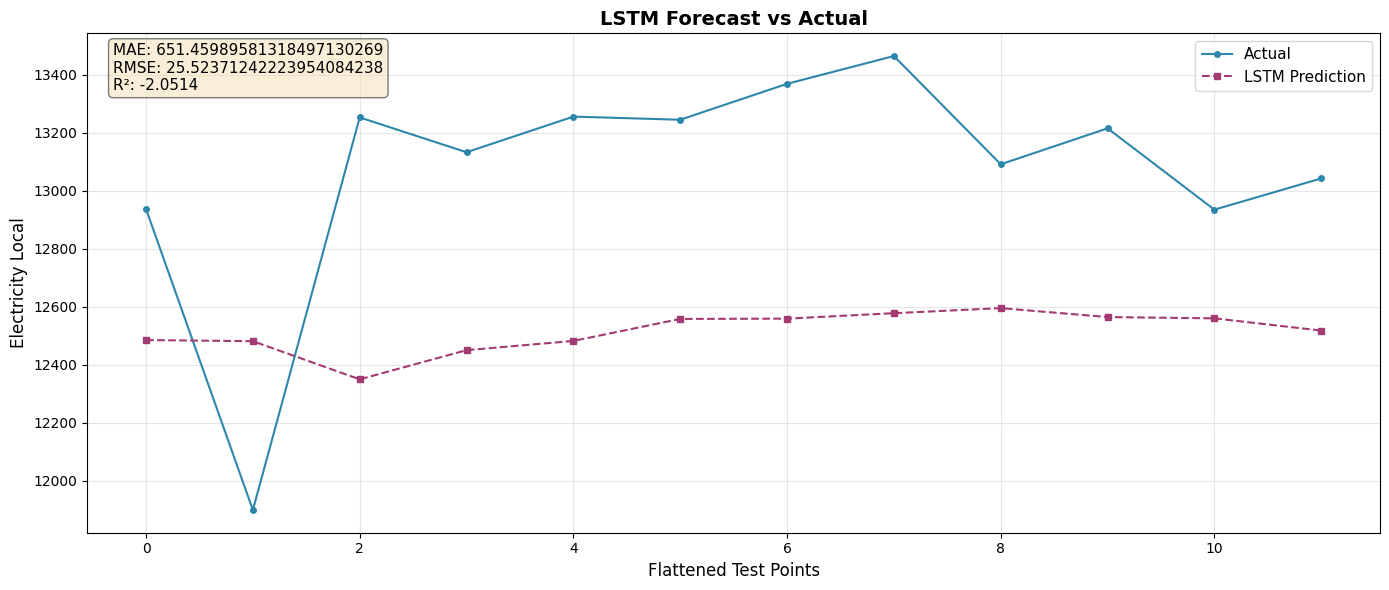


✓ Forecast completed successfully!


In [11]:
# Create prediction vs actual plot
plt.figure(figsize=(14, 6))

# Plot flattened actual values and predictions
plt.plot(y_test_original.flatten(), marker='o', linestyle='-', 
         linewidth=1.5, label='Actual', color='#2E86AB', markersize=4)
plt.plot(y_pred_original.flatten(), marker='s', linestyle='--', 
         linewidth=1.5, label='LSTM Prediction', color='#A23B72', markersize=4)

plt.title('LSTM Forecast vs Actual', fontsize=14, fontweight='bold')
plt.xlabel('Flattened Test Points', fontsize=12)
plt.ylabel('Electricity Local', fontsize=12)
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)

# Add metrics to the plot
metrics_text = f'MAE: {mae_original:.20f}\nRMSE: {rmse_original:.20f}\nR²: {r2_original:.4f}'
plt.text(0.02, 0.98, metrics_text, transform=plt.gca().transAxes, 
         fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"\n✓ Forecast completed successfully!")

# Differenced LSTM Pipeline for electricity_local
This second pipeline keeps the original workflow above intact, but forces first-order differencing on the log-transformed electricity_local series. Running this pipeline saves to the same model filename, replacing the previously saved model.


## Load and Prepare Dataset


In [12]:
# Reload the dataset so this differenced pipeline is independent from the original one above.
df_diff = pd.read_csv('../COS40007DataCleaning/combined_air_electricity_ipi_cleaned.csv')

df_diff['date'] = pd.to_datetime(df_diff['date'])
df_diff = df_diff.sort_values('date').reset_index(drop=True)

target_col = 'electricity_local'
print(f'Differenced forecast target: {target_col}')
print(f'Dataset shape before outlier removal: {df_diff.shape}')
print('First 5 rows:')
print(df_diff[['date', target_col]].head())
print('Last 5 rows:')
print(df_diff[['date', target_col]].tail())

z_scores = np.abs(zscore(df_diff[target_col]))

df_diff[target_col] = np.where(
    z_scores > 3,
    np.nan,
    df_diff[target_col]
)

df_diff[target_col] = df_diff[target_col].interpolate()
print('First 5 rows after outlier smoothing:')
print(df_diff[['date', target_col]].head())
print('Last 5 rows after outlier smoothing:')
print(df_diff[['date', target_col]].tail())


Differenced forecast target: electricity_local
Dataset shape before outlier removal: (60, 20)
First 5 rows:
        date  electricity_local
0 2018-01-01       11845.900250
1 2018-02-01       11091.957006
2 2018-03-01       12244.089947
3 2018-04-01       12018.584577
4 2018-05-01       12267.998390
Last 5 rows:
         date  electricity_local
55 2022-08-01       13463.730428
56 2022-09-01       13090.583108
57 2022-10-01       13214.603633
58 2022-11-01       12934.276582
59 2022-12-01       13041.875463
First 5 rows after outlier smoothing:
        date  electricity_local
0 2018-01-01       11845.900250
1 2018-02-01       11091.957006
2 2018-03-01       12244.089947
3 2018-04-01       12018.584577
4 2018-05-01       12267.998390
Last 5 rows after outlier smoothing:
         date  electricity_local
55 2022-08-01       13463.730428
56 2022-09-01       13090.583108
57 2022-10-01       13214.603633
58 2022-11-01       12934.276582
59 2022-12-01       13041.875463


## Force Log Differencing


In [13]:
df_diff.set_index('date', inplace=True)
df_diff[f'log_{target_col}'] = np.log(df_diff[target_col])
log_series_diff = df_diff[f'log_{target_col}']

# Force first-order differencing for this second pipeline.
difference_order_diff = 1
processed_series_diff = log_series_diff.diff().dropna()

print(f'Log transformation and first-order differencing applied to {target_col}.')
print('ADF test on differenced log series:')
run_adf_test(processed_series_diff)

print(f'Final differenced data length: {len(processed_series_diff)}')
data_diff = processed_series_diff.values.reshape(-1, 1)
print(f'Data shape: {data_diff.shape}')


Log transformation and first-order differencing applied to electricity_local.
ADF test on differenced log series:
ADF statistic: -6.1918, p-value: 0.0000, usedlag: 3, nobs: 55
Final differenced data length: 59
Data shape: (59, 1)


## Split Differenced Data into Train and Test


In [14]:
test_size_diff = 12
train_data_diff = data_diff[:-test_size_diff]
test_data_diff = data_diff[-test_size_diff:]

print(f'Train data shape: {train_data_diff.shape}')
print(f'Test data shape: {test_data_diff.shape}')
print(f'Train range: {len(train_data_diff)} months')
print(f'Test range: {len(test_data_diff)} months')


Train data shape: (47, 1)
Test data shape: (12, 1)
Train range: 47 months
Test range: 12 months


## Scale Differenced Data


In [15]:
scaler_diff = MinMaxScaler(feature_range=(0, 1))
train_scaled_diff = scaler_diff.fit_transform(train_data_diff)
test_scaled_diff = scaler_diff.transform(test_data_diff)

print(f'Scaled train shape: {train_scaled_diff.shape}')
print(f'Scaled test shape: {test_scaled_diff.shape}')
print(f'Scaler min: {scaler_diff.data_min_[0]:.6f}, max: {scaler_diff.data_max_[0]:.6f}')


Scaled train shape: (47, 1)
Scaled test shape: (12, 1)
Scaler min: -0.132701, max: 0.111310


## Create Differenced LSTM Input Sequences


In [16]:
def create_sequences_diff(data, lookback=3):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i, 0:1])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

lookback_diff = 3

X_train_diff, y_train_diff = create_sequences_diff(train_scaled_diff, lookback_diff)

test_extended_diff = np.vstack((train_scaled_diff[-lookback_diff:], test_scaled_diff))
X_test_diff, y_test_diff = create_sequences_diff(test_extended_diff, lookback_diff)

print(f'X_train shape: {X_train_diff.shape}')
print(f'X_test shape: {X_test_diff.shape}')
print(f'Selected lookback from ACF: {lookback_diff}')


X_train shape: (44, 3, 1)
X_test shape: (12, 3, 1)
Selected lookback from ACF: 3


## Train the Differenced Model


In [17]:
print('Training the differenced LSTM model with walk-forward validation...')

def create_model_diff(lookback=3):
    model = Sequential([
        LSTM(8, input_shape=(lookback, 1),
             kernel_regularizer=l2(1e-4),
             recurrent_regularizer=l2(1e-4)),
        Dense(4, activation='relu', kernel_regularizer=l2(1e-4)),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def walk_forward_validation_diff(scaled_data, lookback=3, val_size=4, n_splits=3):
    total_len = len(scaled_data)
    max_splits = (total_len - lookback - val_size) // val_size
    if max_splits < 1:
        raise ValueError('Not enough data for walk-forward validation with the given parameters.')

    n_splits = min(n_splits, max_splits)
    metrics = []

    for split in range(n_splits):
        initial_train_size = 20
        train_end = initial_train_size + (split + 1) * val_size
        val_start = train_end
        val_end = val_start + val_size

        if val_end > total_len:
            print(f'Fold {split + 1}: not enough data, skipping.')
            break

        train_window = scaled_data[:train_end]
        val_window = scaled_data[val_start:val_end]

        X_train_w, y_train_w = create_sequences_diff(train_window, lookback)
        X_val_w, y_val_w = create_sequences_diff(
            np.vstack((train_window[-lookback:], val_window)),
            lookback
        )

        fold_model = create_model_diff(lookback)
        fold_model.fit(
            X_train_w,
            y_train_w,
            epochs=200,
            batch_size=2,
            validation_data=(X_val_w, y_val_w),
            callbacks=[
                EarlyStopping(
                    monitor='val_loss',
                    patience=20,
                    restore_best_weights=True,
                    verbose=0
                ),
                ReduceLROnPlateau(
                    monitor='val_loss',
                    factor=0.5,
                    patience=10,
                    min_lr=1e-5,
                    verbose=0
                )
            ],
            shuffle=False,
            verbose=0
        )

        y_val_pred = fold_model.predict(X_val_w, verbose=0)
        mae = mean_absolute_error(y_val_w, y_val_pred)
        rmse = np.sqrt(mean_squared_error(y_val_w, y_val_pred))
        r2 = r2_score(y_val_w, y_val_pred)
        metrics.append((mae, rmse, r2))

        print(
            f'Fold {split + 1}: train_end={train_end}, val_end={val_end}, '
            f'MAE={mae:.6f}, RMSE={rmse:.6f}, R2={r2:.6f}'
        )

    return metrics

metrics_diff = walk_forward_validation_diff(train_scaled_diff, lookback=lookback_diff, val_size=4, n_splits=3)

mae_values_diff = [m[0] for m in metrics_diff]
rmse_values_diff = [m[1] for m in metrics_diff]
r2_values_diff = [m[2] for m in metrics_diff]

print('Walk-forward validation summary:')
print(f'Average MAE:  {np.mean(mae_values_diff):.6f}')
print(f'Average RMSE: {np.mean(rmse_values_diff):.6f}')
print(f'Average R2:   {np.mean(r2_values_diff):.6f}')

print('Training final differenced model on the full training set...')
model = create_model_diff(lookback_diff)
history_diff = model.fit(
    X_train_diff,
    y_train_diff,
    epochs=200,
    batch_size=2,
    validation_split=0.15,
    callbacks=[
        EarlyStopping(
            monitor='val_loss',
            patience=20,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=10,
            min_lr=1e-5,
            verbose=1
        )
    ],
    shuffle=False,
    verbose=1
)

print('Differenced training completed!')


Training the differenced LSTM model with walk-forward validation...
Fold 1: train_end=24, val_end=28, MAE=0.091773, RMSE=0.093023, R2=-0.658370
Fold 2: train_end=28, val_end=32, MAE=0.103972, RMSE=0.126488, R2=-0.995612
Fold 3: train_end=32, val_end=36, MAE=0.082033, RMSE=0.111654, R2=0.088245
Walk-forward validation summary:
Average MAE:  0.092592
Average RMSE: 0.110389
Average R2:   -0.521912
Training final differenced model on the full training set...
Epoch 1/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.3786 - val_loss: 0.3792 - learning_rate: 0.0010
Epoch 2/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3133 - val_loss: 0.3336 - learning_rate: 0.0010
Epoch 3/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2848 - val_loss: 0.3156 - learning_rate: 0.0010
Epoch 4/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2675 - val_loss: 0.2985 - learning_rate: 0.0010
Epoch 5/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2510 - val_loss: 0.2822 - learning_rate: 0.

## Evaluate the Differenced Model


In [18]:
y_pred_scaled_diff = model.predict(X_test_diff, verbose=0)

mae_scaled_diff = mean_absolute_error(y_test_diff, y_pred_scaled_diff)
rmse_scaled_diff = np.sqrt(mean_squared_error(y_test_diff, y_pred_scaled_diff))
r2_scaled_diff = r2_score(y_test_diff, y_pred_scaled_diff)

print('=== Metrics on Scaled Differenced Data ===')
print(f'MAE (scaled): {mae_scaled_diff:.6f}')
print(f'RMSE (scaled): {rmse_scaled_diff:.6f}')
print(f'R2 (scaled):   {r2_scaled_diff:.6f}')

# 1. Save the model architecture to a JSON file
model_json = model.to_json()
with open("lstm_model_electric_local_forecast.json", "w") as json_file:
    json_file.write(model_json)

# 2. Save the weights to a separate HDF5 file
model.save_weights("lstm_model_electric_local_forecast.weights.h5")

=== Metrics on Scaled Differenced Data ===
MAE (scaled): 0.100984
RMSE (scaled): 0.168559
R2 (scaled):   -0.000301


## Inverse Transform Differenced Predictions


In [19]:
y_pred_diff_values = scaler_diff.inverse_transform(y_pred_scaled_diff.reshape(-1, 1))
y_test_diff_values = scaler_diff.inverse_transform(y_test_diff.reshape(-1, 1))

# For first-order differencing, each predicted difference is added to the actual
# log value immediately before the corresponding test point.
prev_log_values = log_series_diff.iloc[-test_size_diff - 1:-1].values.reshape(-1, 1)
y_pred_log_values_diff = y_pred_diff_values + prev_log_values
y_test_log_values_diff = log_series_diff.iloc[-test_size_diff:].values.reshape(-1, 1)

y_pred_original_diff = np.exp(y_pred_log_values_diff)
y_test_original_diff = np.exp(y_test_log_values_diff)

assert y_pred_original_diff.shape == y_test_original_diff.shape, \
    f'Shape mismatch! Preds: {y_pred_original_diff.shape}, Actuals: {y_test_original_diff.shape}'
assert len(y_pred_original_diff) == test_size_diff, \
    f'Expected {test_size_diff} predictions, got {len(y_pred_original_diff)}'

mae_original_diff = mean_absolute_error(y_test_original_diff, y_pred_original_diff)
rmse_original_diff = np.sqrt(mean_squared_error(y_test_original_diff, y_pred_original_diff))
r2_original_diff = r2_score(y_test_original_diff, y_pred_original_diff)

print('=== Metrics on Original Scale, Differenced Pipeline ===')
print(f'MAE (original): {mae_original_diff:.20f}')
print(f'RMSE (original): {rmse_original_diff:.20f}')
print(f'R2   (original): {r2_original_diff:.6f}')


=== Metrics on Original Scale, Differenced Pipeline ===
MAE (original): 314.14331272646722936770
RMSE (original): 517.19741914379380887112
R2   (original): -0.808923


## Plot Differenced Pipeline Forecast


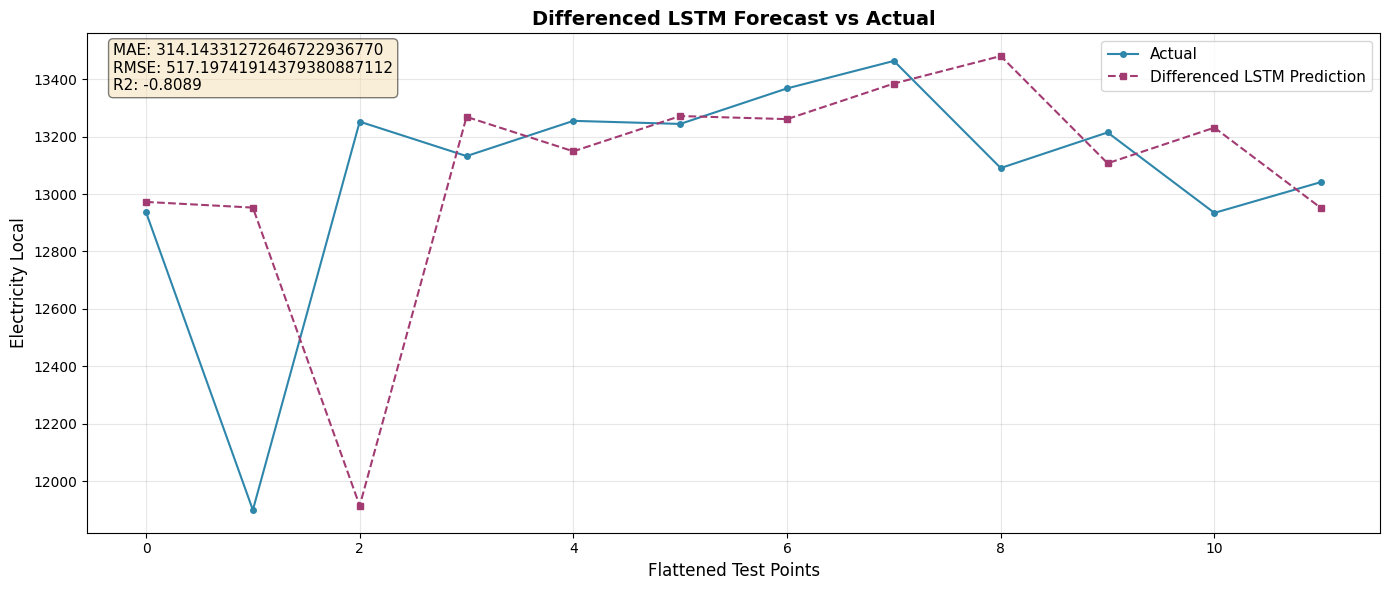

Differenced forecast completed successfully!


In [20]:
plt.figure(figsize=(14, 6))

plt.plot(y_test_original_diff.flatten(), marker='o', linestyle='-',
         linewidth=1.5, label='Actual', color='#2E86AB', markersize=4)
plt.plot(y_pred_original_diff.flatten(), marker='s', linestyle='--',
         linewidth=1.5, label='Differenced LSTM Prediction', color='#A23B72', markersize=4)

plt.title('Differenced LSTM Forecast vs Actual', fontsize=14, fontweight='bold')
plt.xlabel('Flattened Test Points', fontsize=12)
plt.ylabel('Electricity Local', fontsize=12)
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)

metrics_text = f'MAE: {mae_original_diff:.20f}\nRMSE: {rmse_original_diff:.20f}\nR2: {r2_original_diff:.4f}'
plt.text(0.02, 0.98, metrics_text, transform=plt.gca().transAxes,
         fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print('Differenced forecast completed successfully!')
